In [32]:
import numpy as np
import matplotlib.pyplot as plt

In [49]:
cubic = "./ab140_out/horizon_cubic.npy"
idw = "./ab140_out/horizon_idw.npy"
kriging = "./ab140_out/horizon_kriging.npy"
linear = "./ab140_out/horizon_linear.npy"
nearest = "./ab140_out/horizon_nearest.npy"
rbf = "./ab140_out/horizon_rbf.npy"

In [50]:
cubic = np.load(cubic)
idw = np.load(idw)
kriging = np.load(kriging)
linear = np.load(linear)
nearest = np.load(nearest)
rbf = np.load(rbf)

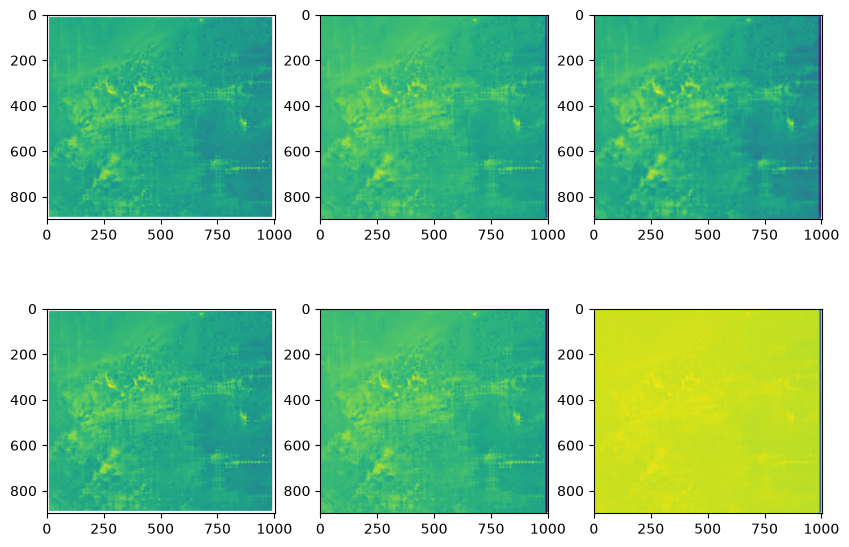

In [51]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

axes[0, 0].imshow(cubic)
axes[0, 1].imshow(idw)
axes[0, 2].imshow(kriging)
axes[1, 0].imshow(linear)
axes[1, 1].imshow(nearest)
axes[1, 2].imshow(rbf)

plt.show()

In [52]:
cubic.shape

(900, 1002)

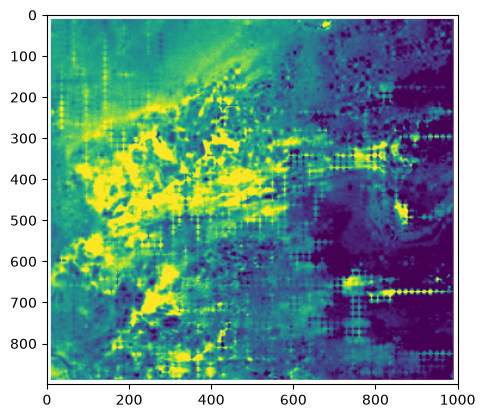

In [55]:
plt.imshow(cubic, vmin=5400, vmax=7000)

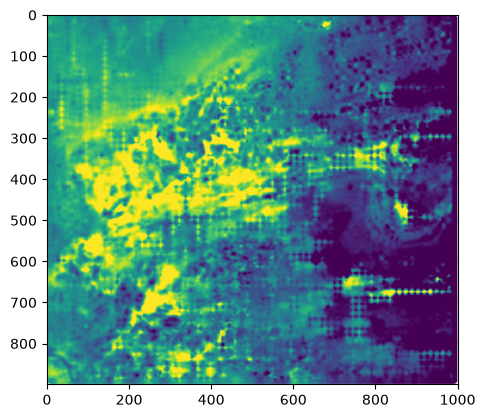

In [56]:
plt.imshow(idw, vmin=5400, vmax=7000)

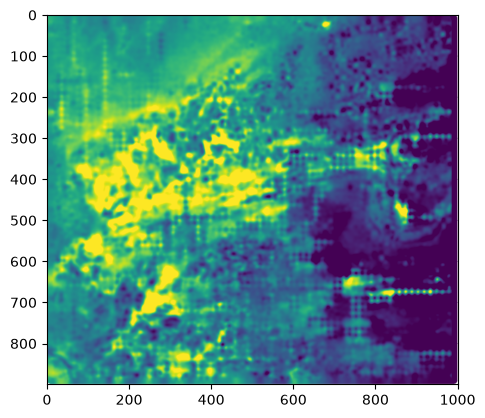

In [57]:
plt.imshow(kriging, vmin=5400, vmax=7000)

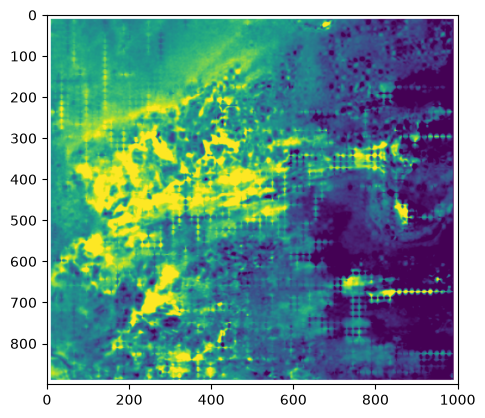

In [58]:
plt.imshow(linear, vmin=5400, vmax=7000)

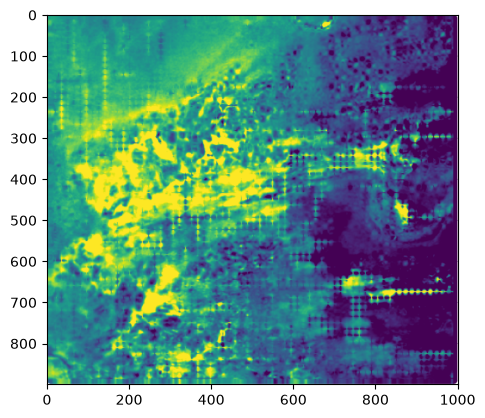

In [59]:
plt.imshow(nearest, vmin=5400, vmax=7000)

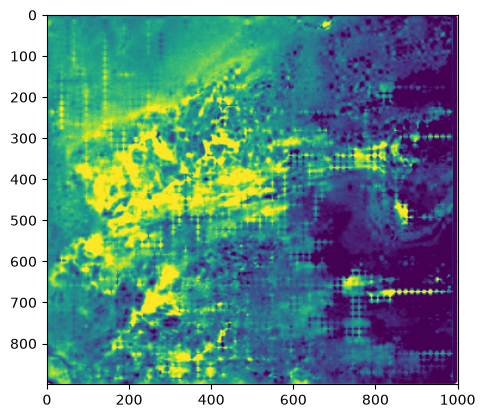

In [60]:
plt.imshow(rbf, vmin=5400, vmax=7000)

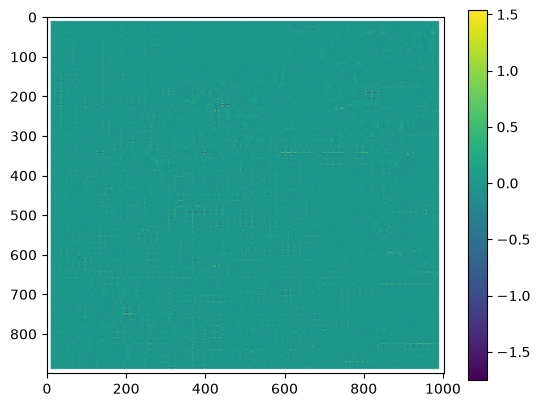

In [43]:
plt.imshow(
    linear - cubic
)
plt.colorbar()

In [44]:
def plot_horizons(surface):
    plt.imshow(surface, cmap="gist_rainbow_r")
    plt.colorbar()
    plt.show()

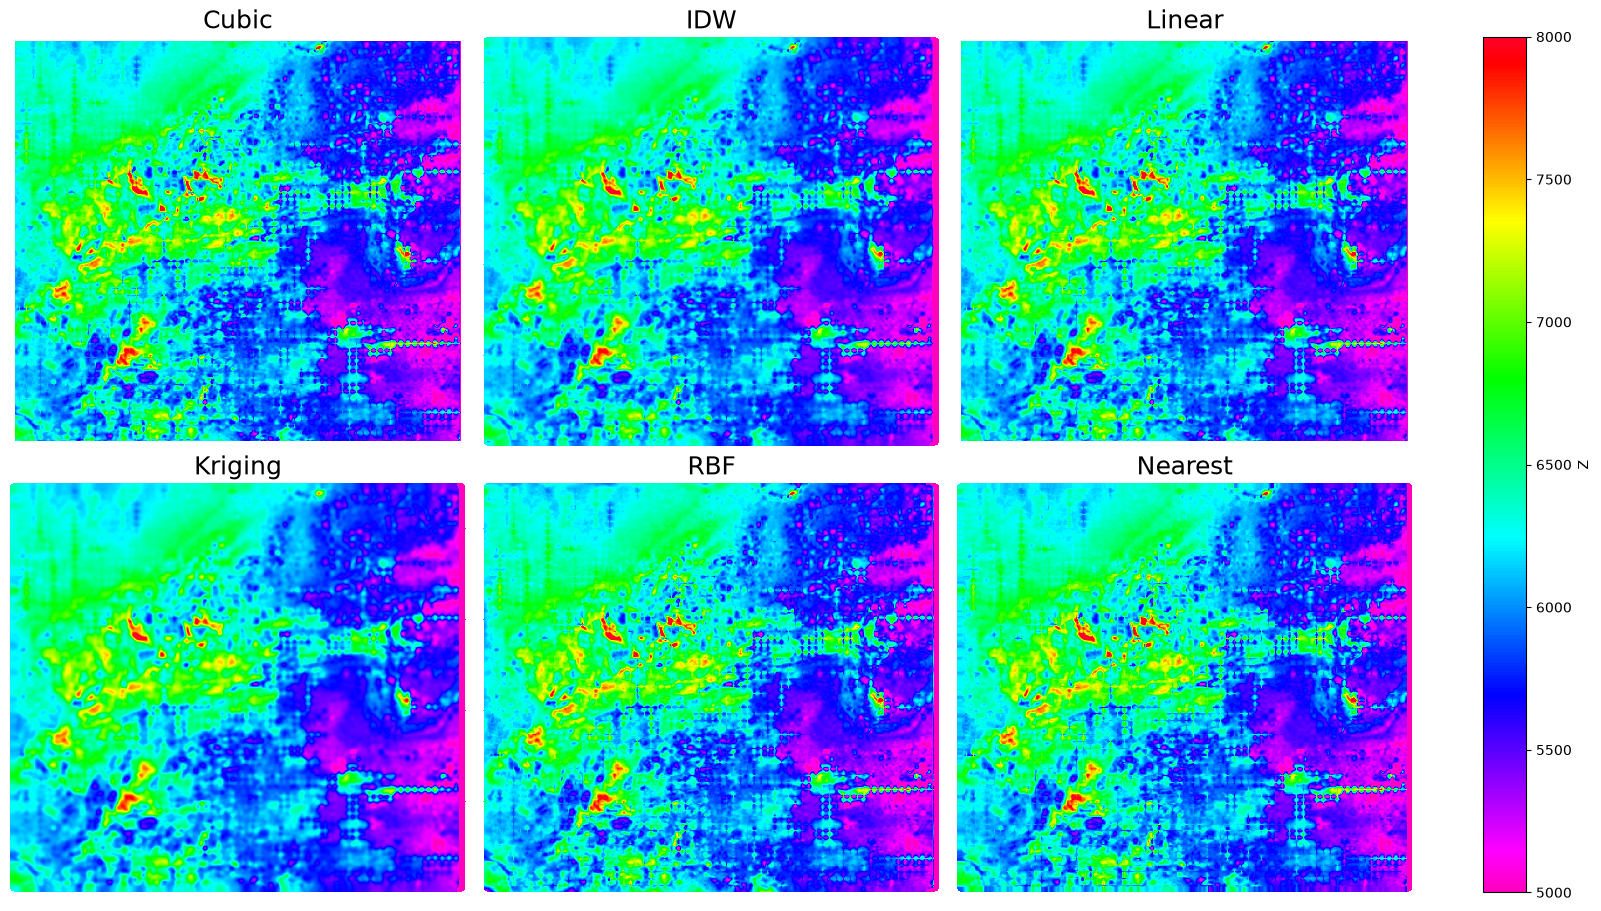

In [70]:
import numpy as np
import matplotlib.pyplot as plt

surfaces = {
    "Cubic": cubic,
    "IDW": idw,
    "Linear": linear,
    "Kriging": kriging,
    "RBF": rbf,
    "Nearest": nearest,
}

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 9),
    constrained_layout=True,
)

for ax, (name, surface) in zip(axes.flat, surfaces.items()):
    im = ax.imshow(
        surface,
        cmap="gist_rainbow_r",
        vmin=5000,
        vmax=8000,
        interpolation="nearest",
    )
    ax.set_title(name, fontsize=18)
    ax.axis("off")

fig.colorbar(im, ax=axes, label="Z")

fig.savefig(
    "horizon_interpolation_4k999999.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

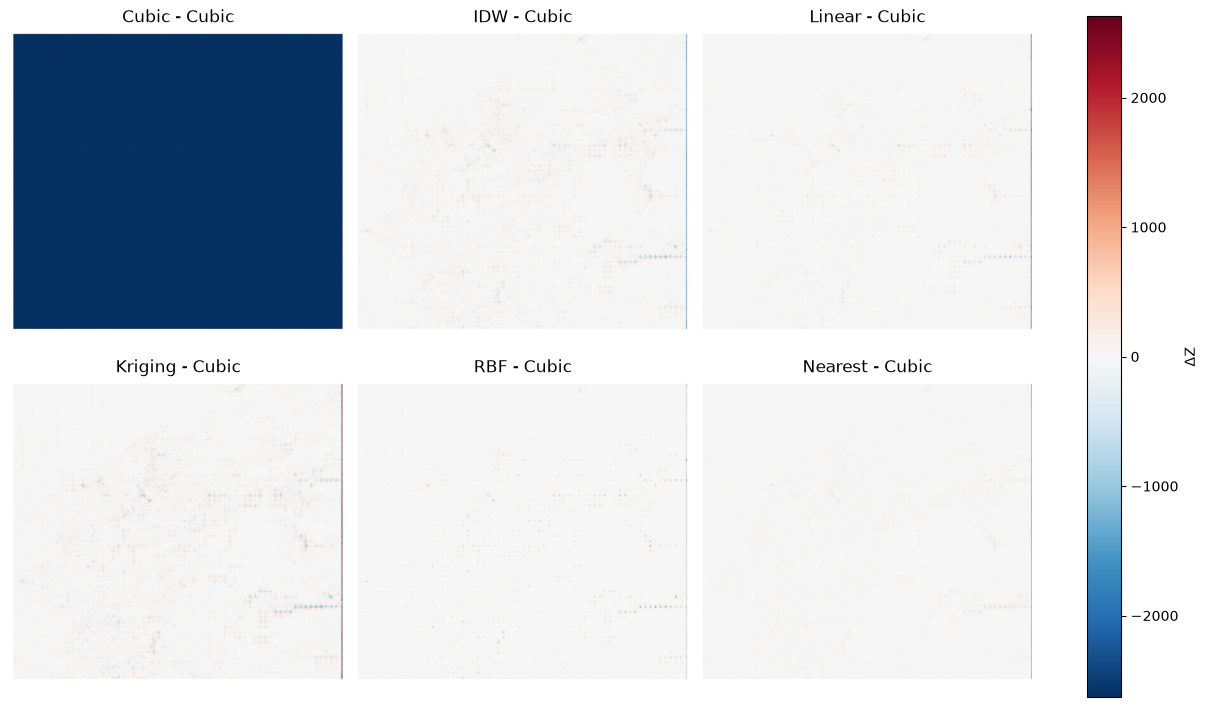

In [63]:
ref = cubic

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)

diffs = {}

for ax, (name, surface) in zip(axes.flat, surfaces.items()):
    diff = surface - ref
    diffs[name] = diff

    vmax = np.nanmax(np.abs(diff))

    im = ax.imshow(
        diff,
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
    )

    ax.set_title(f"{name} - Cubic")
    ax.axis("off")

fig.colorbar(im, ax=axes, label="ΔZ")
plt.show()

In [64]:
for name, surface in surfaces.items():
    diff = surface - ref

    print(
        f"{name:8s} "
        f"MAE={np.nanmean(np.abs(diff)):.4f}  "
        f"RMSE={np.sqrt(np.nanmean(diff**2)):.4f}  "
        f"Max={np.nanmax(np.abs(diff)):.4f}"
    )

Cubic    MAE=0.0000  RMSE=0.0000  Max=0.0000
IDW      MAE=26.1762  RMSE=55.7129  Max=1357.4819
Linear   MAE=9.1943  RMSE=26.6571  Max=764.7744
Kriging  MAE=57.2876  RMSE=121.1656  Max=2261.9697
RBF      MAE=2.3030  RMSE=6.2929  Max=248.3735
Nearest  MAE=28.1484  RMSE=81.2973  Max=2628.8118


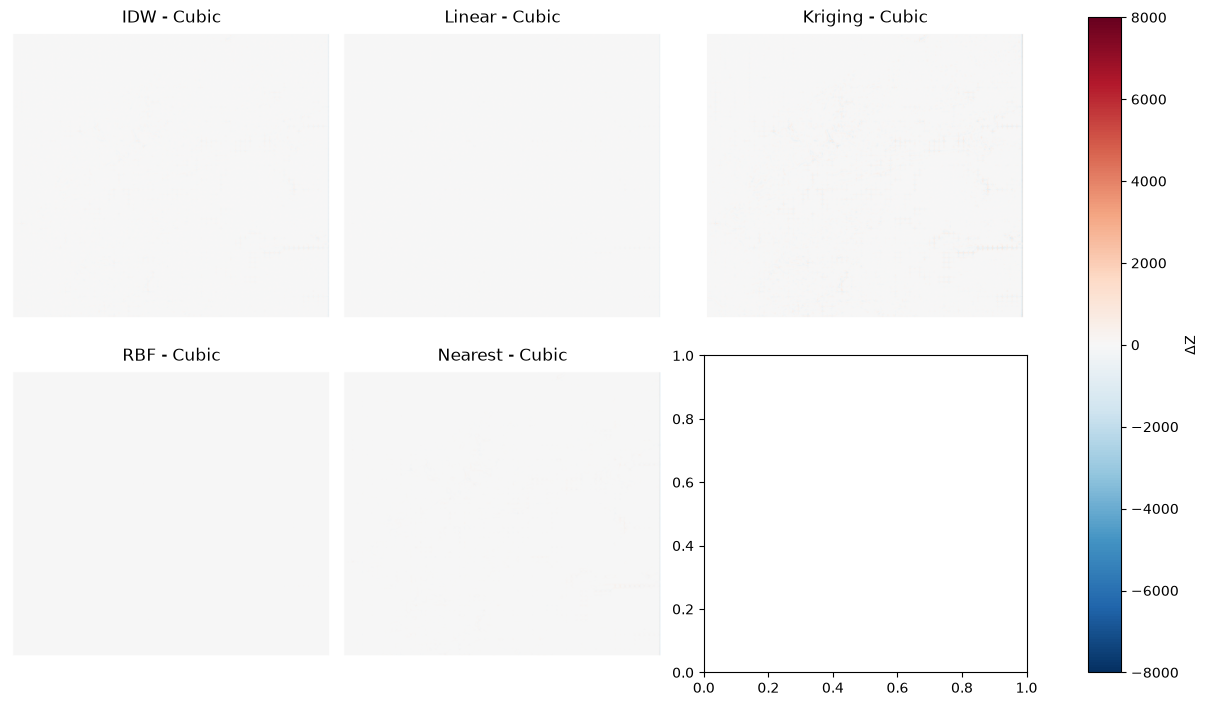

In [66]:
ref = cubic

fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)

diffs = {
    name: surface - ref
    for name, surface in surfaces.items()
    if name != "Cubic"
}

vmax = max(np.nanmax(np.abs(d)) for d in diffs.values())

for ax, (name, diff) in zip(axes.flat, diffs.items()):
    im = ax.imshow(
        diff,
        cmap="RdBu_r",
        vmin=-8000,
        vmax=8000,
    )
    ax.set_title(f"{name} - Cubic")
    ax.axis("off")

fig.colorbar(im, ax=axes, label="ΔZ")
plt.show()